# EDA Combinado — Todos los Tipos de Material M402
## Corporación Multi Inversiones · Mayo 2026
---
**Proyecto:** Asistente Inteligente de Gestión de Materiales SAP  
**Equipo:** Alejandra Alvarado · Rudy Osorio · Erick Marroquin  
**Programa:** MBIA · Universidad del Valle de Guatemala  
**Fecha corte datos:** 29 de mayo 2026

### Objetivo
Comparar todos los tipos de material del mandante 402 en un análisis unificado para:
1. Identificar qué tipo concentra más duplicados
2. Comparar completitud entre tipos
3. Construir el dataset maestro consolidado


In [1]:
# ── Resolucion de rutas (agregado al importar al repositorio GAMMA) ──────
# Localiza data/xlsx tanto dentro del contenedor Jupyter como en ejecucion local,
# sin importar la profundidad del notebook respecto de lab/.
import os

def _find_data_dir():
    if os.path.isdir('/home/jovyan/work/data/xlsx'):
        return '/home/jovyan/work/data/xlsx'
    d = os.path.abspath('.')
    for _ in range(6):
        cand = os.path.join(d, 'data', 'xlsx')
        if os.path.isdir(cand):
            return cand
        d = os.path.dirname(d)
    raise FileNotFoundError('No se encontro el directorio data/xlsx')

DATA_DIR = _find_data_dir()
FIG_DIR  = os.path.join(os.path.abspath('.'), 'figuras')
os.makedirs(FIG_DIR, exist_ok=True)
print('DATA_DIR:', DATA_DIR)
print('FIG_DIR :', FIG_DIR)


DATA_DIR: /Users/menene/code/www/mbia_gamma/lab/data/xlsx
FIG_DIR : /Users/menene/code/www/mbia_gamma/lab/notebooks/eda/figuras


## 1. Carga Combinada de Todos los Tipos

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import warnings
warnings.filterwarnings('ignore')

# Paleta corporativa CMI
CMI_VERDE  = '#1A6635'
CMI_CLARO  = '#D6EFE0'
CMI_ORO    = '#C9A84C'
CMI_GRIS   = '#4A4A4A'
CMI_ROJO   = '#C0392B'

Z_FILES = ['ZCON_29MAY26.xlsx', 'ZEQU_29MAY26.xlsx', 'ZHAR_29MAY26.xlsx', 'ZHER_29MAY26.xlsx', 'ZMAF_29MAY26.xlsx', 'ZMAQ_29MAY26.xlsx', 'ZMER MOB OFI VEH TUB_29MAY26.xlsx', 'ZQUI_29MAY26.xlsx', 'ZRPA_29MAY26.xlsx', 'ZRPI_29MAY26.xlsx', 'ZSEG_29MAY26.xlsx', 'ZSUM_29MAY26.xlsx']
CLASES_FILE = 'Clases de material DEN.xlsx'

dfs = []
for f in Z_FILES:
    try:
        tmp = pd.read_excel(os.path.join(DATA_DIR, f))
        if 'Texto breve de material.1' in tmp.columns:
            tmp = tmp.rename(columns={'Texto breve de material.1': 'Texto_breve_2'})
        tipo = f.split('_')[0]
        tmp['__tipo__'] = tipo
        tmp['__archivo__'] = f
        dfs.append(tmp)
        print(f'  ✓  {tipo:<30} {len(tmp):>8,} registros')
    except FileNotFoundError:
        print(f'  ✗  {f} — archivo no encontrado')

df_all = pd.concat(dfs, ignore_index=True)
print(f'\nTotal combinado: {len(df_all):,} registros · {df_all["__tipo__"].nunique()} tipos')


  ✓  ZCON                              1,692 registros
  ✓  ZEQU                                145 registros
  ✓  ZHAR                                384 registros
  ✓  ZHER                              2,033 registros
  ✓  ZMAF                                 80 registros
  ✓  ZMAQ                                 93 registros
  ✓  ZMER MOB OFI VEH TUB              2,552 registros


  ✓  ZQUI                              5,667 registros
  ✓  ZRPA                                337 registros


  ✓  ZRPI                             15,861 registros
  ✓  ZSEG                              2,626 registros


  ✓  ZSUM                             13,399 registros

Total combinado: 44,869 registros · 12 tipos


## 2. Comparación de Tamaño por Tipo

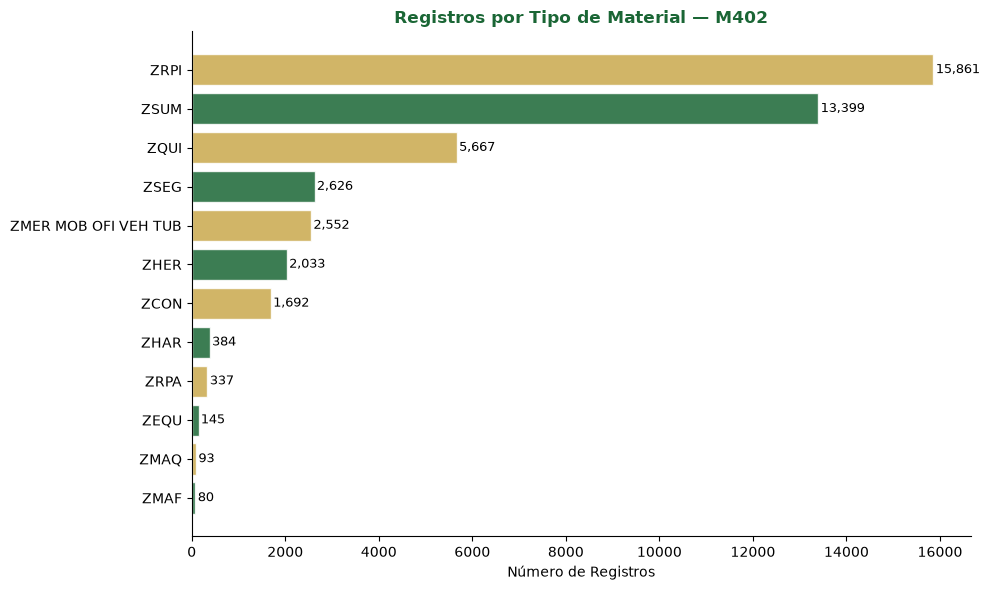

In [3]:
conteo = df_all['__tipo__'].value_counts().sort_values(ascending=True)
fig, ax = plt.subplots(figsize=(10, 6))
colores = [CMI_VERDE if i % 2 == 0 else CMI_ORO for i in range(len(conteo))]
bars = ax.barh(conteo.index, conteo.values, color=colores, edgecolor='white', alpha=0.85)
for bar, val in zip(bars, conteo.values):
    ax.text(val + 50, bar.get_y() + bar.get_height()/2,
            f'{val:,}', va='center', fontsize=9)
ax.set_xlabel('Número de Registros')
ax.set_title('Registros por Tipo de Material — M402', fontweight='bold', color=CMI_VERDE)
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'fig_comb1_tamano.png'), dpi=150, bbox_inches='tight')
plt.show()


## 3. Tasa de Duplicados por Tipo

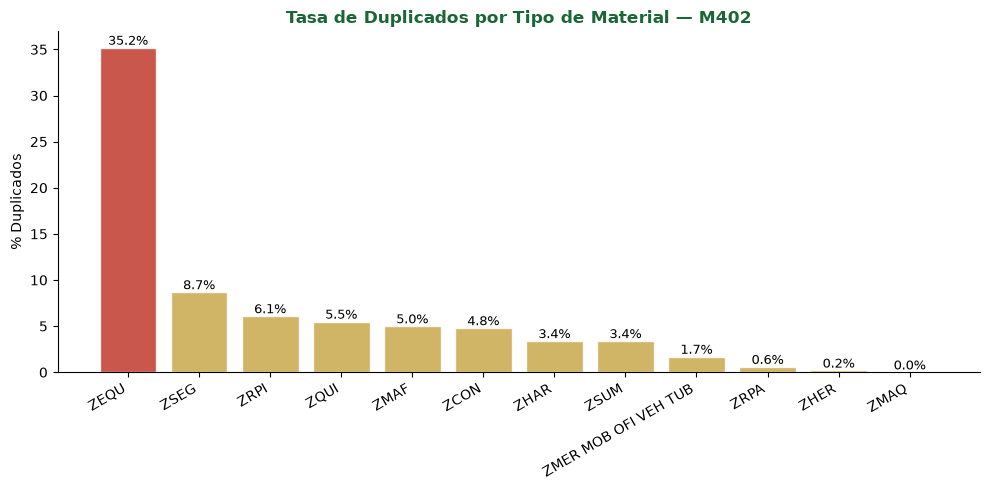

In [4]:
col_texto = 'Texto breve de material'
resumen = []
for tipo, grp in df_all.groupby('__tipo__'):
    if col_texto not in grp.columns:
        continue
    dup = grp.duplicated(subset=[col_texto], keep=False).sum()
    col_pb = next((c for c in grp.columns if 'PB' in c or 'nivel' in c.lower()), None)
    bloq = (grp[col_pb] == 'X').sum() if col_pb else 0
    tiene_sep = grp[col_texto].astype(str).str.contains(r'[:/;]', regex=True)
    sin_sep = (~tiene_sep).sum()
    resumen.append({
        'Tipo': tipo,
        'Total': len(grp),
        'Duplicados': dup,
        'Pct_Dup': round(dup / len(grp) * 100, 1),
        'Bloqueados': bloq,
        'Pct_Bloq': round(bloq / len(grp) * 100, 1),
        'Sin_Separador': sin_sep,
        'Pct_SinSep': round(sin_sep / len(grp) * 100, 1),
    })

df_res = pd.DataFrame(resumen).sort_values('Pct_Dup', ascending=False)

fig, ax = plt.subplots(figsize=(10, 5))
colores = [CMI_ROJO if p > 10 else CMI_ORO for p in df_res['Pct_Dup']]
bars = ax.bar(df_res['Tipo'], df_res['Pct_Dup'], color=colores, edgecolor='white', alpha=0.85)
for bar, val in zip(bars, df_res['Pct_Dup']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f'{val}%', ha='center', fontsize=9)
ax.set_ylabel('% Duplicados')
ax.set_title('Tasa de Duplicados por Tipo de Material — M402', fontweight='bold', color=CMI_VERDE)
ax.spines[['top','right']].set_visible(False)
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'fig_comb2_duplicados.png'), dpi=150, bbox_inches='tight')
plt.show()


## 4. Tabla Resumen Comparativa

                Tipo  Total  Duplicados  Pct_Dup  Bloqueados  Pct_Bloq  Sin_Separador  Pct_SinSep
                ZEQU    145          51     35.2          35      24.1              4         2.8
                ZSEG   2626         229      8.7         253       9.6            207         7.9
                ZRPI  15861         973      6.1           0       0.0           1800        11.3
                ZQUI   5667         314      5.5        1004      17.7            347         6.1
                ZMAF     80           4      5.0           1       1.2             10        12.5
                ZCON   1692          81      4.8         354      20.9            108         6.4
                ZHAR    384          13      3.4          78      20.3              4         1.0
                ZSUM  13399         456      3.4        2539      18.9            505         3.8
ZMER MOB OFI VEH TUB   2552          43      1.7         701      27.5            107         4.2
                ZRPA

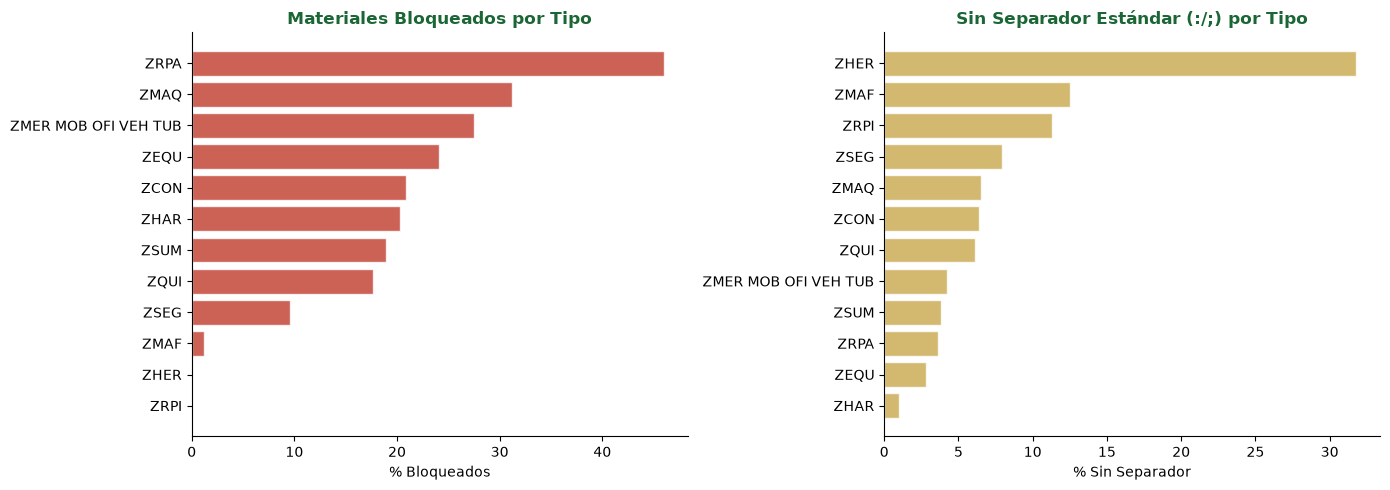

In [5]:
print(df_res.to_string(index=False))

# Gráfico bloqueados vs sin separador
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

df_plot = df_res.sort_values('Pct_Bloq', ascending=True)
axes[0].barh(df_plot['Tipo'], df_plot['Pct_Bloq'], color=CMI_ROJO, alpha=0.8, edgecolor='white')
axes[0].set_xlabel('% Bloqueados')
axes[0].set_title('Materiales Bloqueados por Tipo', fontweight='bold', color=CMI_VERDE)
axes[0].spines[['top','right']].set_visible(False)

df_plot2 = df_res.sort_values('Pct_SinSep', ascending=True)
axes[1].barh(df_plot2['Tipo'], df_plot2['Pct_SinSep'], color=CMI_ORO, alpha=0.8, edgecolor='white')
axes[1].set_xlabel('% Sin Separador')
axes[1].set_title('Sin Separador Estándar (:/;) por Tipo', fontweight='bold', color=CMI_VERDE)
axes[1].spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'fig_comb3_comparativo.png'), dpi=150, bbox_inches='tight')
plt.show()
